# DeepLearning — Codebase Index

Quick-navigation reference for every `.py` file and notebook in this project.  
Run the cell below to render the **dependency graph** and the **full reference table**.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Registry ──────────────────────────────────────────────────────────────────
FILES = [
    {
        "file":  "array_types.py",
        "kind":  "types",
        "color": "#6366f1",
        "exports": ["ArrayFunction", "Chain"],
        "imports": [],
        "functions": [
            ("ArrayFunction", "type alias — Callable[[ndarray], ndarray]"),
            ("Chain",         "type alias — list[ArrayFunction]"),
        ],
        "note": "Shared type definitions used across the whole project.",
    },
    {
        "file":  "derivative.py",
        "kind":  "math",
        "color": "#0891b2",
        "exports": ["deriv"],
        "imports": [],
        "functions": [
            ("deriv(func, input_, delta=0.001)", "Numerical central-difference derivative of func at every element of input_"),
        ],
        "note": "Core numerical differentiation utility. Used by all backward-pass files.",
    },
    {
        "file":  "nested_function.py",
        "kind":  "math",
        "color": "#0891b2",
        "exports": ["chain_length_2"],
        "imports": ["array_types → Chain"],
        "functions": [
            ("chain_length_2(chain, a)", "Evaluates two functions in sequence: f2(f1(a))"),
        ],
        "note": "Also re-exports Chain (imported by chain_deriv_2/3).",
    },
    {
        "file":  "mat_mul.py",
        "kind":  "forward",
        "color": "#16a34a",
        "exports": ["matmul_forward"],
        "imports": [],
        "functions": [
            ("matmul_forward(X, W)", "Forward pass of matrix multiplication: X @ W → N"),
        ],
        "note": "Standalone — has __main__ block with usage examples.",
    },
    {
        "file":  "mat_mul_backward_first.py",
        "kind":  "backward",
        "color": "#dc2626",
        "exports": ["mat_mul_backward_first"],
        "imports": [],
        "functions": [
            ("mat_mul_backward_first(X, W)", "dN/dX = W.T  (backward pass of matmul w.r.t. X)"),
        ],
        "note": "Simplest backward pass — just a transpose.",
    },
    {
        "file":  "matrix_forward_extra.py",
        "kind":  "forward",
        "color": "#16a34a",
        "exports": ["matrix_forward_extra"],
        "imports": ["array_types → ArrayFunction"],
        "functions": [
            ("matrix_forward_extra(X, W, sigma)", "Forward: N = X@W, then S = σ(N)  →  returns S (matrix)"),
        ],
        "note": "One step beyond matmul — applies activation but does NOT sum.",
    },
    {
        "file":  "matrix_function_forward_sum.py",
        "kind":  "forward",
        "color": "#16a34a",
        "exports": ["matrix_function_forward_sum"],
        "imports": ["array_types → ArrayFunction"],
        "functions": [
            ("matrix_function_forward_sum(X, W, sigma)", "Forward: N=X@W → S=σ(N) → L=sum(S)  →  returns scalar L"),
        ],
        "note": "Collapses the whole pipeline to a single loss scalar.",
    },
    {
        "file":  "matrix_function_backward_1.py",
        "kind":  "backward",
        "color": "#dc2626",
        "exports": ["matrix_function_backward_1"],
        "imports": ["array_types → ArrayFunction", "derivative → deriv"],
        "functions": [
            ("matrix_function_backward_1(X, W, sigma)", "dS/dX = σ'(N) @ W.T  (gradient of forward-sum w.r.t. X)"),
        ],
        "note": "Backward pass counterpart to matrix_function_forward_sum.",
    },
    {
        "file":  "multi_input_derivative.py",
        "kind":  "backward",
        "color": "#dc2626",
        "exports": ["multiple_inputs_add_backward"],
        "imports": ["array_types → ArrayFunction", "derivative → deriv"],
        "functions": [
            ("multiple_inputs_add_backward(x, y, sigma)", "dσ(x+y)/dx and dσ(x+y)/dy — both equal σ'(x+y)"),
        ],
        "note": "Demonstrates gradient of a two-input sum through an activation.",
    },
    {
        "file":  "chain_deriv_2.py",
        "kind":  "chain-rule",
        "color": "#d97706",
        "exports": ["chain_deriv_2", "sigmoid"],
        "imports": ["nested_function → Chain", "derivative → deriv"],
        "functions": [
            ("chain_deriv_2(chain, input_range)", "Chain rule for 2 functions: f2'(f1(x)) * f1'(x)"),
            ("sigmoid(x)",                        "Local sigmoid used for demonstration"),
        ],
        "note": "Used by plot_chain_deriv_2.py.",
    },
    {
        "file":  "chain_deriv_3.py",
        "kind":  "chain-rule",
        "color": "#d97706",
        "exports": ["chain_deriv_3", "sigmoid"],
        "imports": ["nested_function → Chain", "derivative → deriv"],
        "functions": [
            ("chain_deriv_3(chain, input_range)", "Chain rule for 3 functions: f3'(f2(f1(x))) * f2'(f1(x)) * f1'(x)"),
            ("sigmoid(x)",                        "Local sigmoid used for demonstration"),
        ],
        "note": "Used by plot_chain_deriv_3.py.",
    },
    {
        "file":  "plot_chain_deriv_2.py",
        "kind":  "plot",
        "color": "#7c3aed",
        "exports": [],
        "imports": ["chain_deriv_2", "nested_function → chain_length_2", "derivative → deriv"],
        "functions": [
            ("(script)", "Plotly figure: sigmoid(x²) and its chain-rule derivative. Saves chain_rule_plot.html"),
        ],
        "note": "Run as a script: python plot_chain_deriv_2.py",
    },
    {
        "file":  "plot_chain_deriv_3.py",
        "kind":  "plot",
        "color": "#7c3aed",
        "exports": [],
        "imports": ["chain_deriv_3", "derivative → deriv"],
        "functions": [
            ("(script)", "Plotly figure: sigmoid(x²)² and its 3-function chain-rule derivative. Saves chain_deriv_2_plot.html"),
        ],
        "note": "Run as a script: python plot_chain_deriv_3.py",
    },
]

NOTEBOOKS = [
    ("index.ipynb",
     "THIS FILE — dependency graph + reference table for all source files and notebooks"),
    ("matrix_function_forward_sum_viz.ipynb",
     "Interactive viz for matrix_function_forward_sum — heatmaps (X, W, N, S), bar chart of S elements, scalar L display, σ and σ' curves"),
    ("matrix_function_backward_1_viz.ipynb",
     "Interactive viz for matrix_function_backward_1 — heatmaps (X, W, N, dSdN, dNdX, grad), σ curve, σ' gradient curve"),
    ("forward_backward_comparison.ipynb",
     "Side-by-side forward vs backward — shared X/W/N (blue), forward side green (S → L, bar chart, σ curve), backward side red (dSdN, dNdX, gradient, σ' curve)"),
]

print(f"Loaded registry: {len(FILES)} source files, {len(NOTEBOOKS)} notebooks.")

Loaded registry: 13 source files, 4 notebooks.


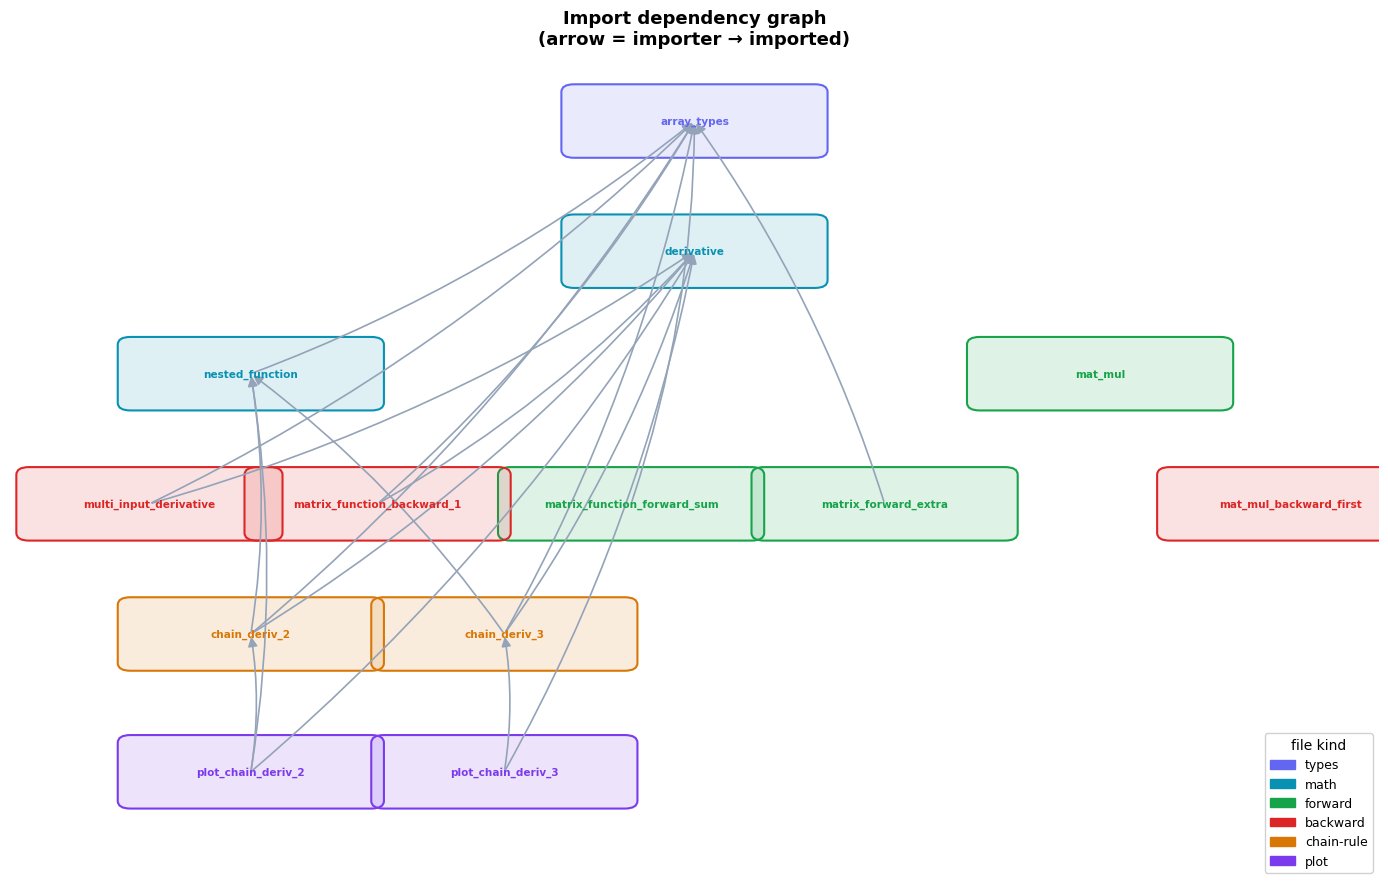

In [2]:
# ── Dependency graph ──────────────────────────────────────────────────────────
# Manual layout positions (x, y) per file
POS = {
    "array_types.py":                  (0.5,  0.95),
    "derivative.py":                   (0.5,  0.78),
    "nested_function.py":              (0.15, 0.62),
    "mat_mul.py":                      (0.82, 0.62),
    "mat_mul_backward_first.py":       (0.97, 0.45),
    "matrix_forward_extra.py":         (0.65, 0.45),
    "matrix_function_forward_sum.py":  (0.45, 0.45),
    "matrix_function_backward_1.py":   (0.25, 0.45),
    "multi_input_derivative.py":       (0.07, 0.45),
    "chain_deriv_2.py":                (0.15, 0.28),
    "chain_deriv_3.py":                (0.35, 0.28),
    "plot_chain_deriv_2.py":           (0.15, 0.10),
    "plot_chain_deriv_3.py":           (0.35, 0.10),
}

# (source_file, target_file) meaning source IMPORTS from target
EDGES = [
    ("nested_function.py",             "array_types.py"),
    ("matrix_forward_extra.py",        "array_types.py"),
    ("matrix_function_forward_sum.py", "array_types.py"),
    ("matrix_function_backward_1.py",  "array_types.py"),
    ("multi_input_derivative.py",      "array_types.py"),
    ("chain_deriv_2.py",               "array_types.py"),
    ("chain_deriv_3.py",               "array_types.py"),
    ("matrix_function_backward_1.py",  "derivative.py"),
    ("multi_input_derivative.py",      "derivative.py"),
    ("chain_deriv_2.py",               "derivative.py"),
    ("chain_deriv_3.py",               "derivative.py"),
    ("plot_chain_deriv_2.py",          "derivative.py"),
    ("plot_chain_deriv_3.py",          "derivative.py"),
    ("chain_deriv_2.py",               "nested_function.py"),
    ("chain_deriv_3.py",               "nested_function.py"),
    ("plot_chain_deriv_2.py",          "nested_function.py"),
    ("plot_chain_deriv_2.py",          "chain_deriv_2.py"),
    ("plot_chain_deriv_3.py",          "chain_deriv_3.py"),
]

COLOR_MAP = {f["file"]: f["color"] for f in FILES}

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(-0.04, 1.04); ax.set_ylim(-0.04, 1.04)
ax.axis("off")
ax.set_title("Import dependency graph\n(arrow = importer → imported)", fontsize=13, fontweight="bold")

# Draw edges first (behind nodes)
for src, tgt in EDGES:
    x0, y0 = POS[src]; x1, y1 = POS[tgt]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="#94a3b8",
                                lw=1.2, mutation_scale=14,
                                connectionstyle="arc3,rad=0.08"))

# Draw nodes
for f in FILES:
    name = f["file"]
    x, y = POS[name]
    short = name.replace(".py", "")
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - 0.095, y - 0.038), 0.19, 0.076,
        boxstyle="round,pad=0.01", linewidth=1.5,
        edgecolor=f["color"], facecolor=f["color"] + "22",
        zorder=2,
    ))
    ax.text(x, y, short, ha="center", va="center", fontsize=7.5,
            fontweight="bold", color=f["color"], zorder=3, wrap=True,
            multialignment="center")

# Legend
kinds = {"types": "#6366f1", "math": "#0891b2",
         "forward": "#16a34a", "backward": "#dc2626",
         "chain-rule": "#d97706", "plot": "#7c3aed"}
patches = [mpatches.Patch(color=c, label=k) for k, c in kinds.items()]
ax.legend(handles=patches, loc="lower right", fontsize=9, title="file kind",
          framealpha=0.9)

plt.tight_layout()
plt.show()

In [3]:
# ── Full reference table ──────────────────────────────────────────────────────
from IPython.display import HTML

rows = []
for f in FILES:
    fns = "<br>".join(
        f"<code>{name}</code> — {desc}" for name, desc in f["functions"]
    )
    imps = "<br>".join(f["imports"]) if f["imports"] else "—"
    rows.append(f"""
      <tr>
        <td style="white-space:nowrap;font-weight:bold;color:{f['color']}">{f['file']}</td>
        <td style="white-space:nowrap">{f['kind']}</td>
        <td>{fns}</td>
        <td style="font-size:0.85em;color:#555">{imps}</td>
        <td style="font-size:0.85em;color:#555">{f['note']}</td>
      </tr>""")

nb_rows = "".join(
    f'<tr><td style="font-weight:bold">{nb}</td><td colspan="4">{desc}</td></tr>'
    for nb, desc in NOTEBOOKS
)

html = f"""
<style>
  table.ref {{ border-collapse:collapse; font-family:monospace; font-size:13px; width:100% }}
  table.ref th {{ background:#1e293b; color:#f8fafc; padding:6px 10px; text-align:left }}
  table.ref td {{ padding:5px 10px; border-bottom:1px solid #e2e8f0; vertical-align:top }}
  table.ref tr:hover td {{ background:#f1f5f9 }}
  .section {{ background:#334155!important; color:#e2e8f0!important; font-size:12px; padding:4px 10px }}
</style>
<table class="ref">
  <thead>
    <tr>
      <th>File</th><th>Kind</th><th>Functions / Symbols</th>
      <th>Imports from</th><th>Notes</th>
    </tr>
  </thead>
  <tbody>
    {''.join(rows)}
    <tr><td class="section" colspan="5">📓 Notebooks</td></tr>
    {nb_rows}
  </tbody>
</table>
"""
HTML(html)

File,Kind,Functions / Symbols,Imports from,Notes
array_types.py,types,"ArrayFunction — type alias — Callable[[ndarray], ndarray]Chain — type alias — list[ArrayFunction]",—,Shared type definitions used across the whole project.
derivative.py,math,"deriv(func, input_, delta=0.001) — Numerical central-difference derivative of func at every element of input_",—,Core numerical differentiation utility. Used by all backward-pass files.
nested_function.py,math,"chain_length_2(chain, a) — Evaluates two functions in sequence: f2(f1(a))",array_types → Chain,Also re-exports Chain (imported by chain_deriv_2/3).
mat_mul.py,forward,"matmul_forward(X, W) — Forward pass of matrix multiplication: X @ W → N",—,Standalone — has __main__ block with usage examples.
mat_mul_backward_first.py,backward,"mat_mul_backward_first(X, W) — dN/dX = W.T (backward pass of matmul w.r.t. X)",—,Simplest backward pass — just a transpose.
matrix_forward_extra.py,forward,"matrix_forward_extra(X, W, sigma) — Forward: N = X@W, then S = σ(N) → returns S (matrix)",array_types → ArrayFunction,One step beyond matmul — applies activation but does NOT sum.
matrix_function_forward_sum.py,forward,"matrix_function_forward_sum(X, W, sigma) — Forward: N=X@W → S=σ(N) → L=sum(S) → returns scalar L",array_types → ArrayFunction,Collapses the whole pipeline to a single loss scalar.
matrix_function_backward_1.py,backward,"matrix_function_backward_1(X, W, sigma) — dS/dX = σ'(N) @ W.T (gradient of forward-sum w.r.t. X)",array_types → ArrayFunctionderivative → deriv,Backward pass counterpart to matrix_function_forward_sum.
multi_input_derivative.py,backward,"multiple_inputs_add_backward(x, y, sigma) — dσ(x+y)/dx and dσ(x+y)/dy — both equal σ'(x+y)",array_types → ArrayFunctionderivative → deriv,Demonstrates gradient of a two-input sum through an activation.
chain_deriv_2.py,chain-rule,"chain_deriv_2(chain, input_range) — Chain rule for 2 functions: f2'(f1(x)) * f1'(x)sigmoid(x) — Local sigmoid used for demonstration",nested_function → Chainderivative → deriv,Used by plot_chain_deriv_2.py.
